# Modelo de Classificação — Prever se uma Venda será Concluída ou Cancelada

Neste notebook vamos treinar um modelo de **Árvore de Decisão** para classificar vendas.
O objetivo é aprender o fluxo básico de Machine Learning com scikit-learn.

## 1. Carregar e Preparar os Dados

In [1]:
import pandas as pd

df = pd.read_csv('../dados/vendas_limpo.csv')

# Receita calculada como coluna auxiliar
df['receita'] = df['quantidade'] * df['preco_unitario']

# Removemos 'pendente' porque não conhecemos o resultado final
df = df[df['status'].isin(['concluída', 'cancelada'])]

print(f'Linhas após filtro: {len(df)}')
print()
print('Distribuição de status:')
print(df['status'].value_counts())

Linhas após filtro: 90

Distribuição de status:
status
concluída    83
cancelada     7
Name: count, dtype: int64


**Observação:** o dataset está desbalanceado — há muito mais vendas concluídas do que canceladas.
Isso é normal em dados reais, mas pode fazer o modelo ficar tendencioso para prever sempre "concluída".
Para esta aula vamos treinar mesmo assim e observar o que acontece nas métricas.

## 2. Definir Features (X) e Target (y)

In [2]:
from sklearn.preprocessing import LabelEncoder

# Target: transformar 'cancelada'→0 e 'concluída'→1
le = LabelEncoder()
y = le.fit_transform(df['status'])
print('Classes:', le.classes_, '→ índices: 0 e 1')

# Features
colunas_features = ['categoria', 'quantidade', 'preco_unitario', 'vendedor', 'regiao', 'receita']
X = df[colunas_features].copy()

# Transformar colunas categóricas em números com get_dummies
X = pd.get_dummies(X, columns=['categoria', 'vendedor', 'regiao'])

print(f'\nShape de X: {X.shape}')
print(f'Shape de y: {y.shape}')
print('\nColunas de X:')
print(X.columns.tolist())

Classes: ['cancelada' 'concluída'] → índices: 0 e 1

Shape de X: (90, 15)
Shape de y: (90,)

Colunas de X:
['quantidade', 'preco_unitario', 'receita', 'categoria_Eletrônicos', 'categoria_Móveis', 'categoria_Periféricos', 'vendedor_Ana Lima', 'vendedor_Carlos Silva', 'vendedor_João Costa', 'vendedor_Não informado', 'vendedor_Pedro Rocha', 'regiao_Centro-Oeste', 'regiao_Nordeste', 'regiao_Sudeste', 'regiao_Sul']


## 3. Dividir em Treino e Teste

Separamos 80% dos dados para treinar o modelo e 20% para testar.
O parâmetro `random_state=42` garante que a divisão seja sempre a mesma — importante para reprodutibilidade.

In [3]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {len(X_treino)} amostras')
print(f'Teste:  {len(X_teste)} amostras')

Treino: 72 amostras
Teste:  18 amostras


## 4. Treinar o Modelo

A **Árvore de Decisão** é um ótimo primeiro modelo: ela aprende regras do tipo
"se quantidade > 3 E categoria = Eletrônicos → concluída".
É fácil de interpretar e não precisa de normalização dos dados.

In [4]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_treino, y_treino)

print('Modelo treinado!')

Modelo treinado!


## 5. Avaliar o Modelo

Três formas de medir o desempenho:
- **Accuracy**: porcentagem de acertos no geral
- **Confusion Matrix**: mostra onde o modelo acertou e onde errou
- **Classification Report**: precision, recall e F1-score por classe

Accuracy no conjunto de teste: 88.89%


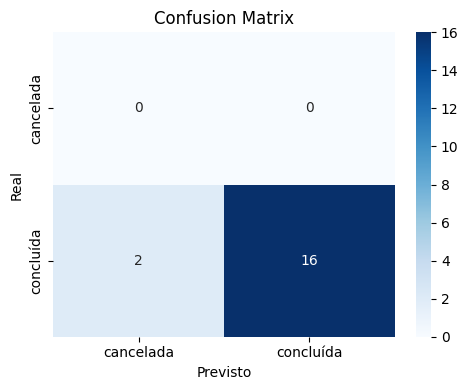


Classification Report:
              precision    recall  f1-score   support

   cancelada       0.00      0.00      0.00         0
   concluída       1.00      0.89      0.94        18

    accuracy                           0.89        18
   macro avg       0.50      0.44      0.47        18
weighted avg       1.00      0.89      0.94        18



In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = modelo.predict(X_teste)

# Accuracy
acc = accuracy_score(y_teste, y_pred)
print(f'Accuracy no conjunto de teste: {acc:.2%}')

# Confusion matrix
cm = confusion_matrix(y_teste, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax
)
ax.set_xlabel('Previsto')
ax.set_ylabel('Real')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Classification report (zero_division=0 evita warning quando uma classe não aparece no teste)
print('\nClassification Report:')
print(classification_report(y_teste, y_pred, target_names=le.classes_, zero_division=0))

## Interpretando os Resultados

A accuracy de **88,89%** parece boa, mas é **enganosa** aqui. Por quê?

- O dataset tem 83 concluídas e só 7 canceladas (92% vs 8%)
- Com tão poucas canceladas, nenhuma delas caiu no conjunto de teste (18 amostras)
- O modelo aprendeu a prever **sempre "concluída"** — e acerta 16 de 18 vezes só por isso

Isso se chama **problema de classes desbalanceadas**. No mundo real, é muito comum.

**O que fazer em seguida (próximas aulas):**
- Usar `stratify=y` no `train_test_split` para garantir que as duas classes apareçam no teste
- Usar técnicas de balanceamento como SMOTE ou `class_weight='balanced'`
- Avaliar pelo F1-score em vez de accuracy